In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surmof_cavity import eps_cav
import matplotlib as mpl

In [2]:
%config InlineBackend.figure_format='retina'

In [3]:
fname = "out/subdivide_smat.pkl"
fname = "core_shell_1pole_dipole_deep_complex_plane.pkl"

with open(fname, "rb") as file:
    results = pickle.load(file)

poles = results['poles']
residues = results['residues']
thickness = results['thickness']


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [4]:
to_THz = 300/2/np.pi
ylim = (300, 500)
npoles = 1

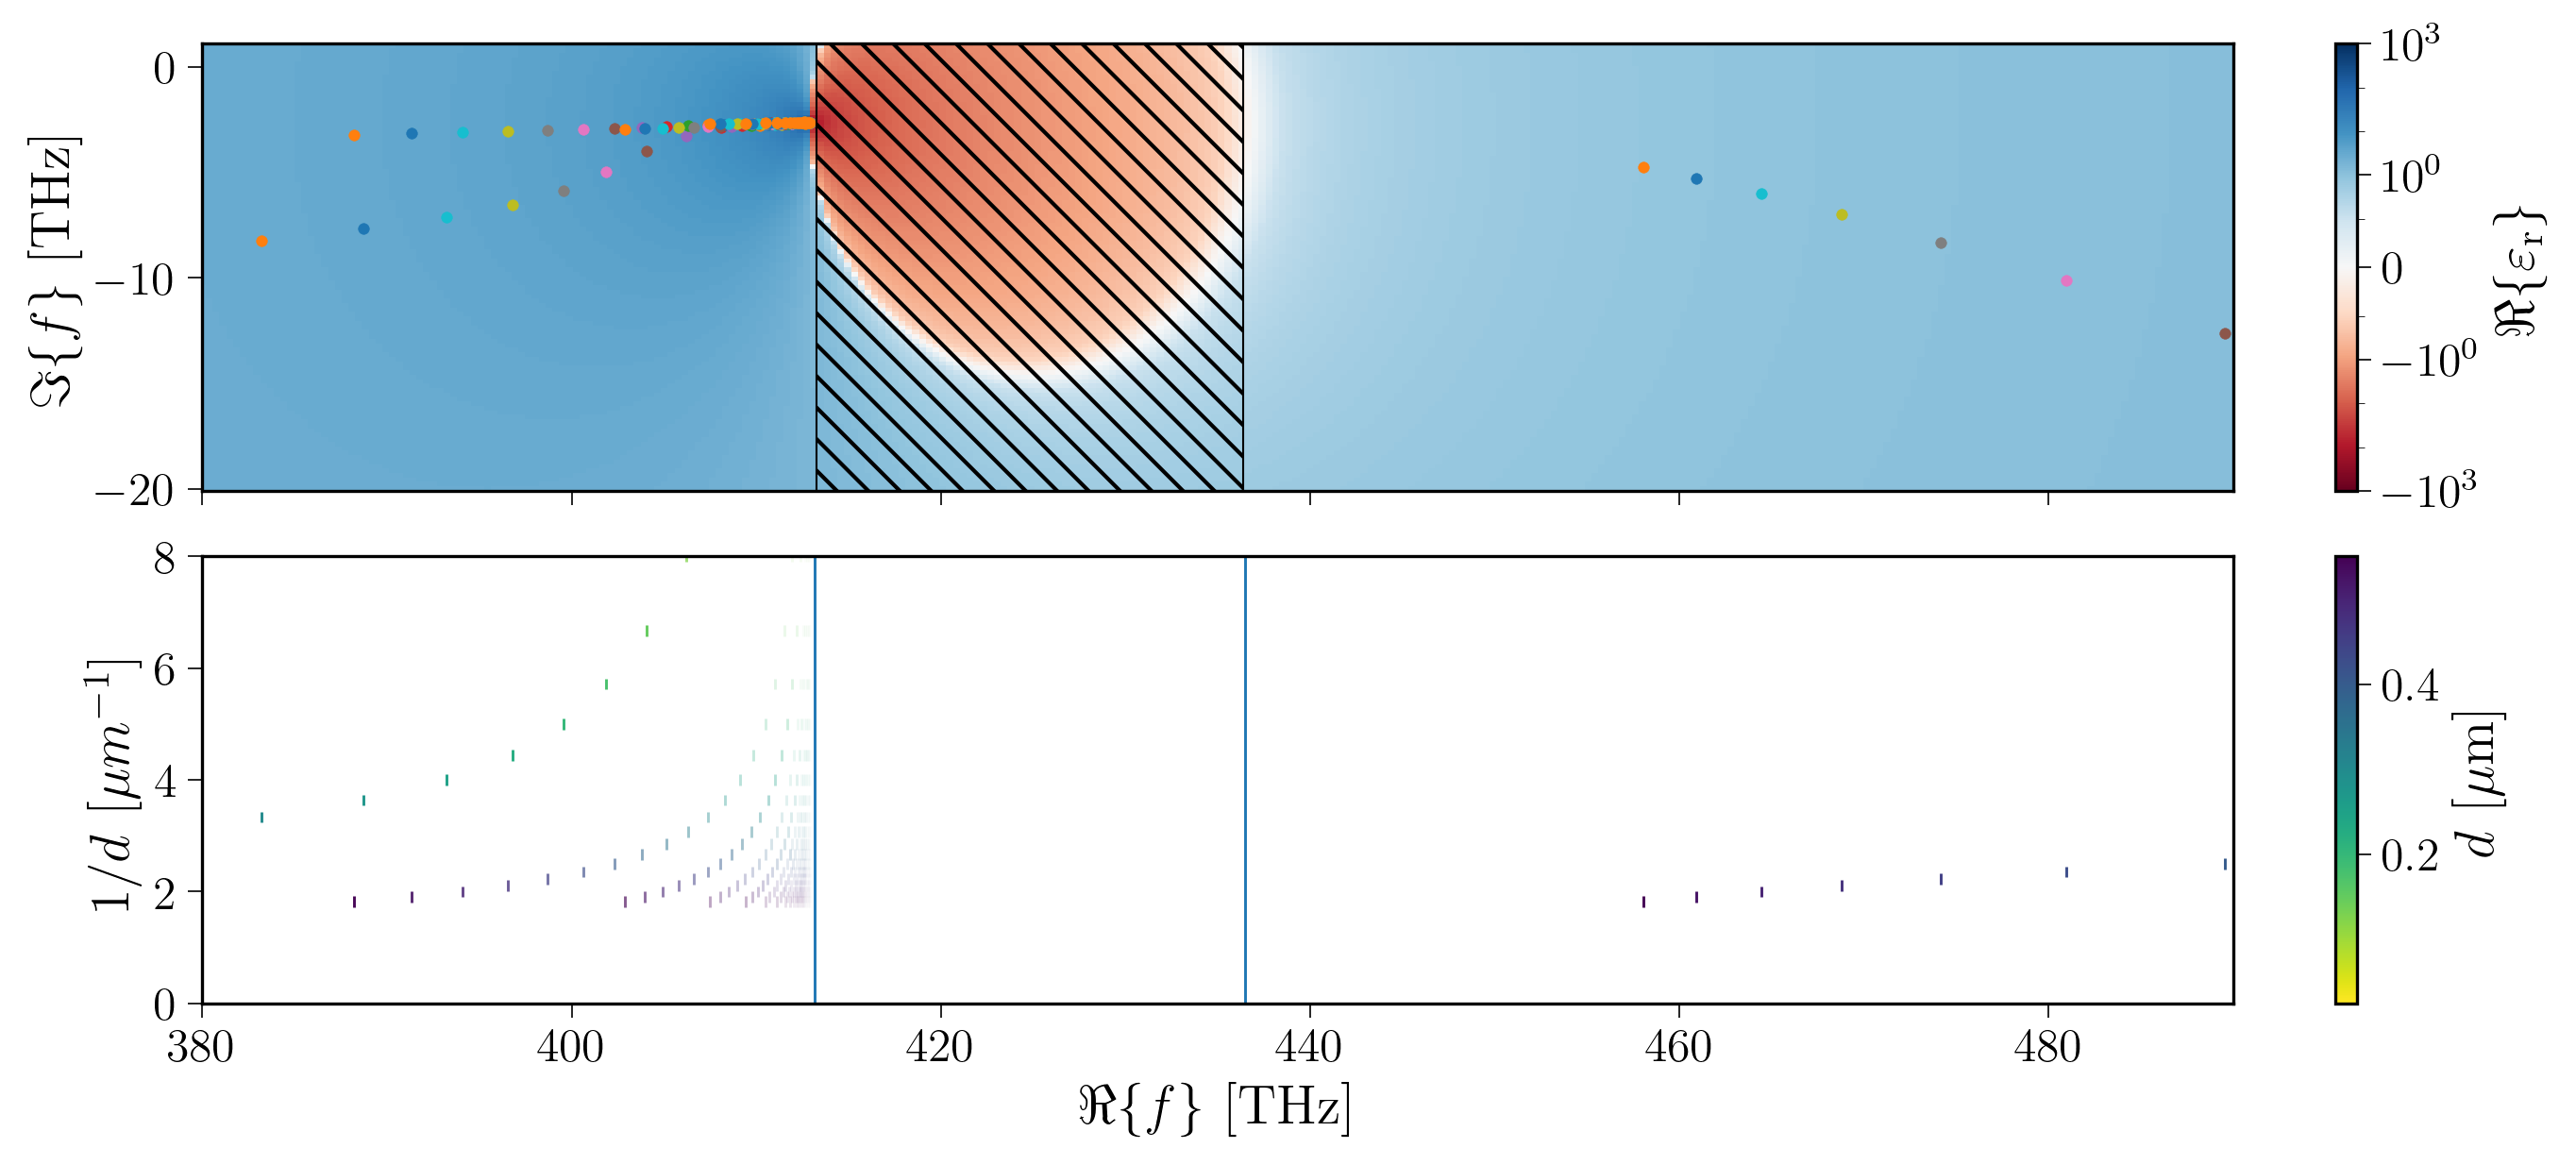

In [5]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(9,4), constrained_layout=True)
plt.sca(axs[0])
w_r = np.linspace(380, 490, 300)
#w_i = np.linspace(-3.7, -2.5, 100)
w_i = np.linspace(-20, 1, 100)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, npoles)

w_r = np.linspace(380, 490, 600)
eps_r = eps_cav(w_r/to_THz, npoles)
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                                              vmin=-1000.0, vmax=1000.0, base=10),
                    cmap="RdBu", rasterized=True)
plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$", ticks=[-1e3, -1, 0, 1, 1e3])

cmap = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))
for color, p, r in zip(colors, poles, residues):
    color=None
    plt.scatter(p.real*to_THz, p.imag*to_THz, color=color)#, s=np.sqrt(np.abs(r))*100)


#plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$\Im\{f\}$ [THz]")
plt.xlim(380, 490)
#plt.ylim(-3.7, -2.5)
plt.savefig("pole_movement.png", dpi=600)

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)

plt.sca(axs[1])
plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="$d$ [$\mathrm{\mu m}$]")
for color, t, p, r in zip(colors, thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [1/t]*len(p), color=color, marker="|", 
                alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylim((0, 8))
plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$1/d$ [$\mu m^{-1}$]")
plt.xlim(min(w_r), max(w_r))

plt.savefig("deep_complex.pdf")

Text(0, 0.5, '$\\Im\\{f\\}$ [THz]')

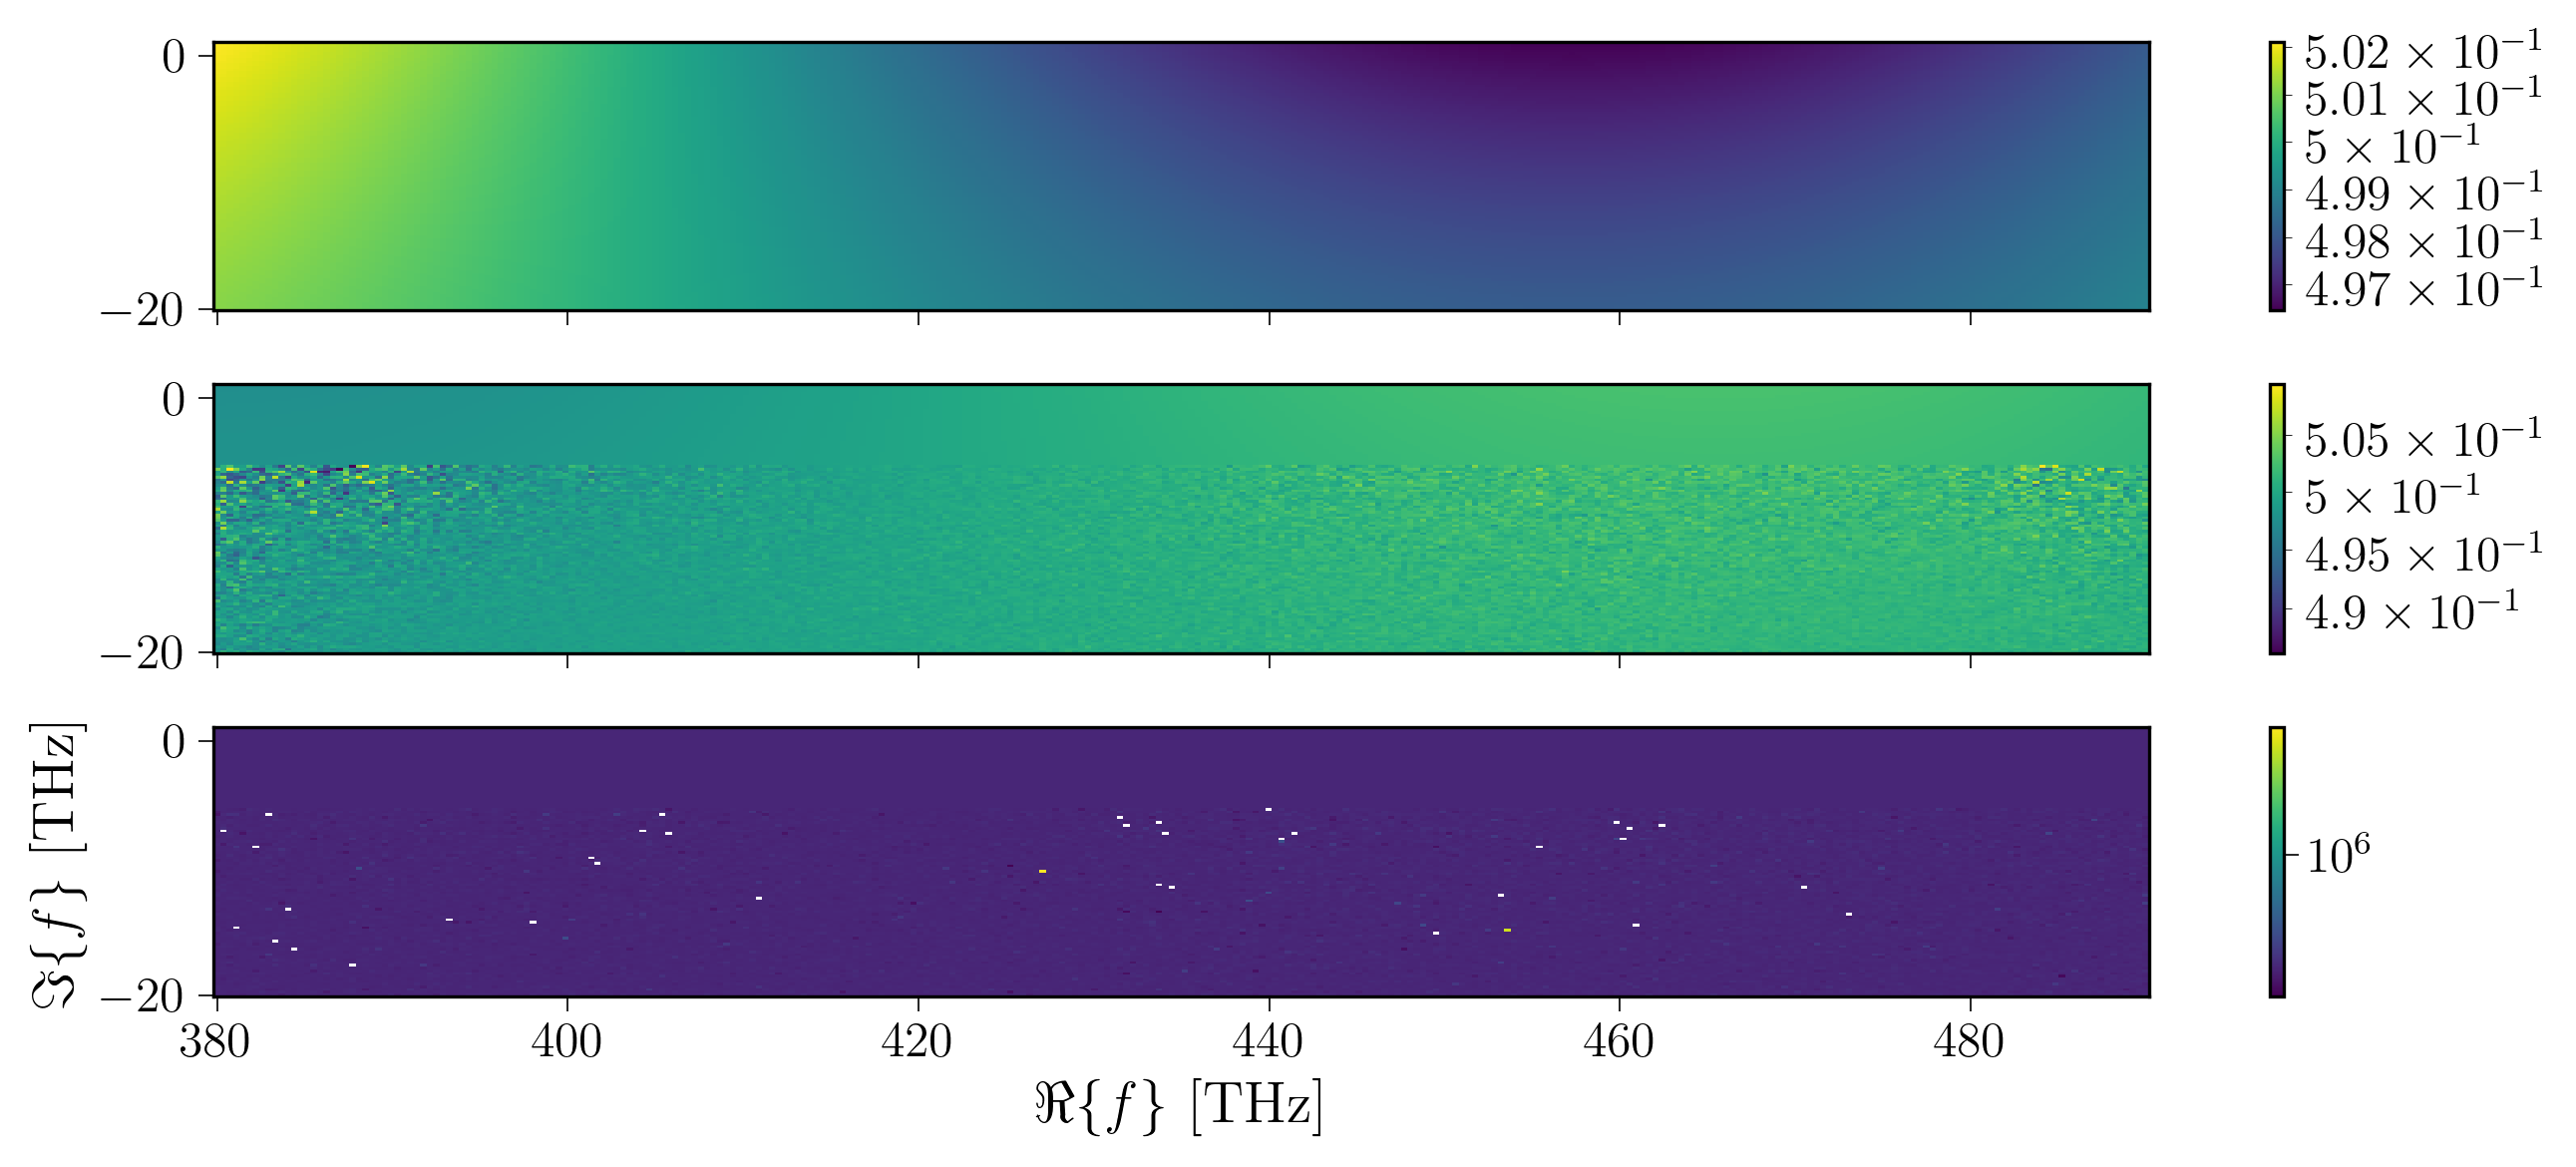

In [6]:
from surmof_cavity import ag_surmof_core_shell as core_shell
fig, axs = plt.subplots(3,1, sharex=True, figsize=(9, 4))
for i, d_core in enumerate([0.5, 0.8, 1]):
    plt.sca(axs[i])
    f = core_shell(W.flatten()/to_THz, d_core=d_core, npoles=1, l=1).reshape(W.shape)
    plt.pcolormesh(W_r, W_i, np.abs(f), norm="log")
    plt.colorbar()
plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$\Im\{f\}$ [THz]")

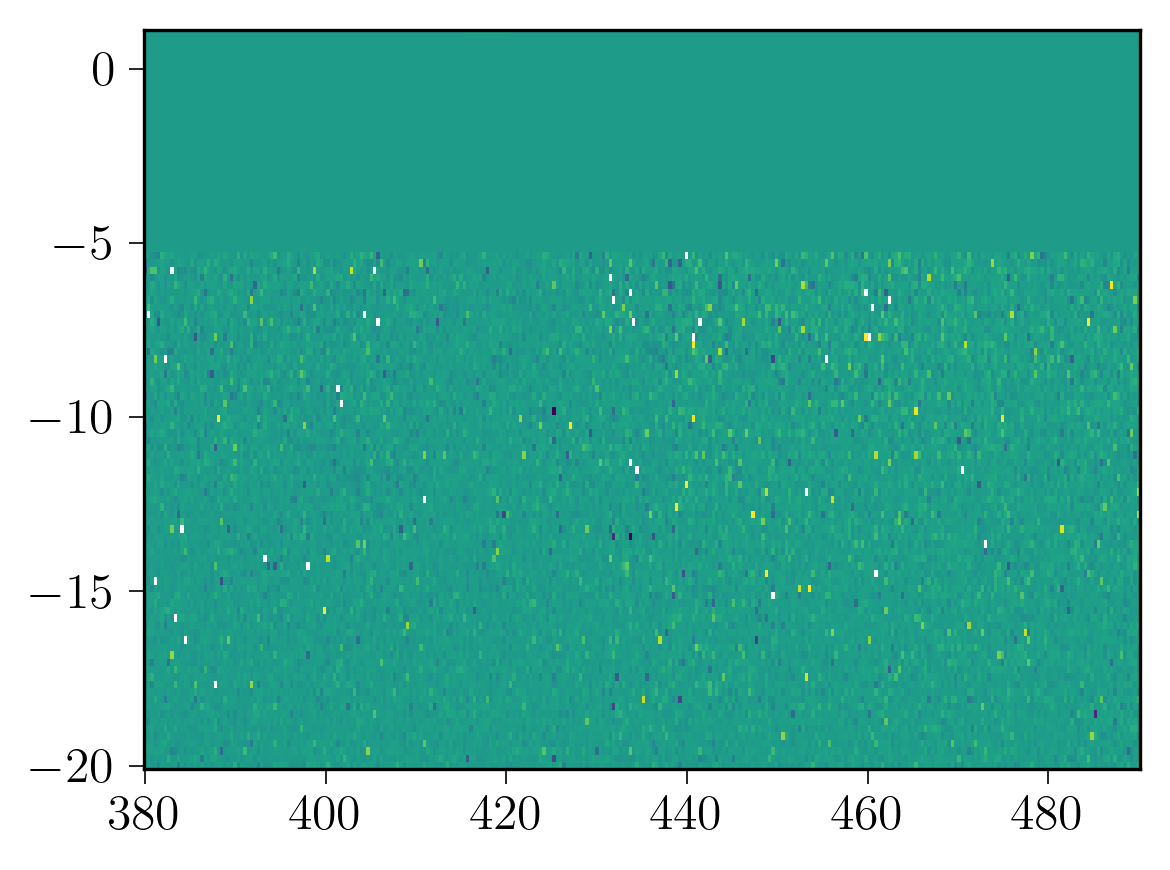

In [7]:
plt.pcolormesh(W_r, W_i, np.abs(f), norm="log", vmax=10)

In [8]:
np.sum(f)

(-15233446234231.145-1338170043485.9995j)

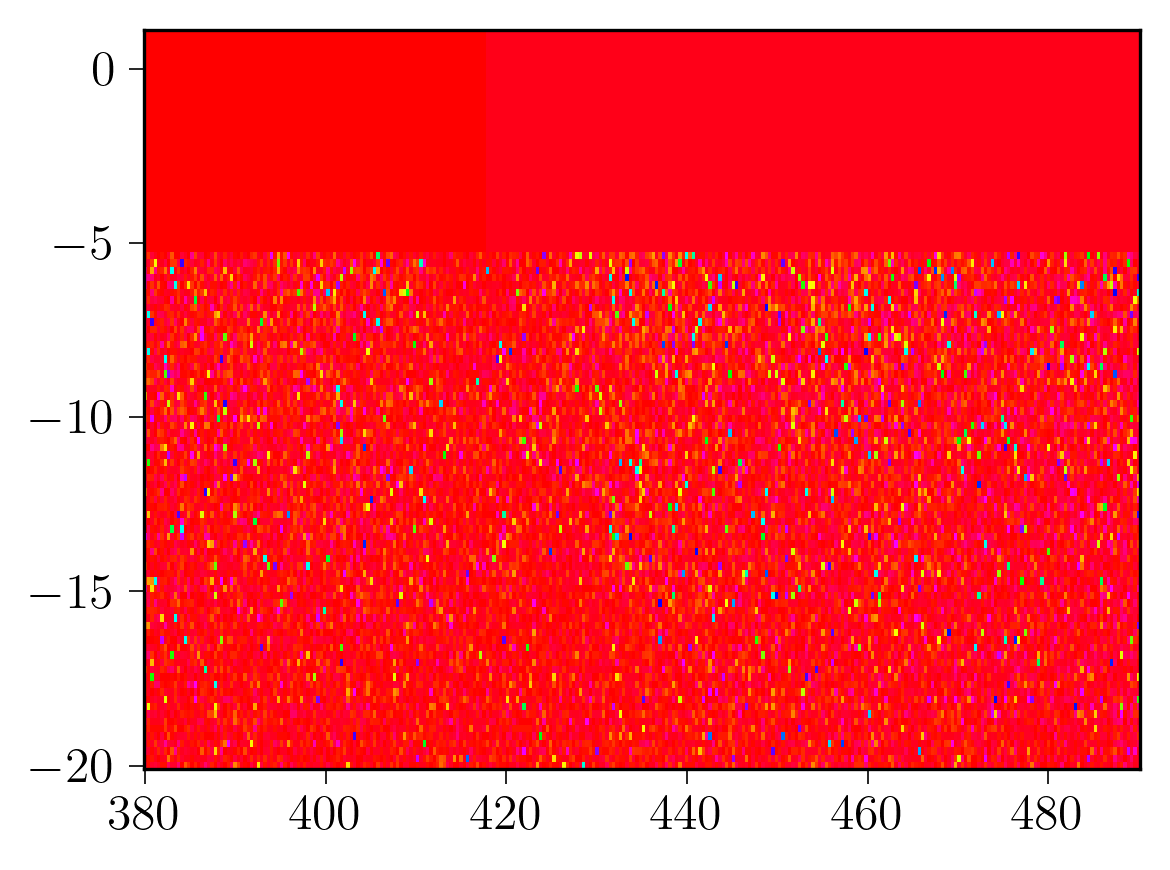

In [9]:
plt.pcolormesh(W_r, W_i, np.angle(f), cmap="hsv")

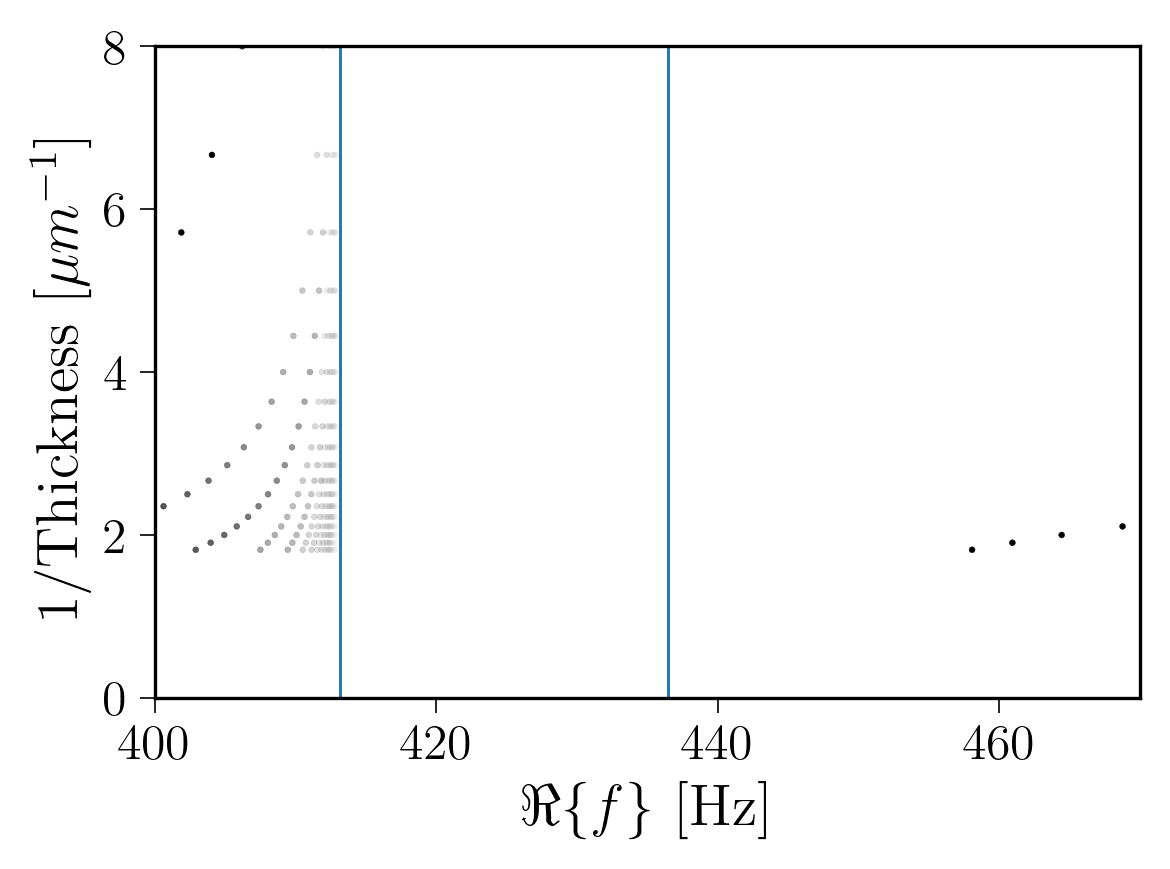

In [10]:
ylim=(400, 470)
for t, p, r in zip(thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [1/t]*len(p), color="k", marker=".", 
                alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylim(0, 8)
plt.xlabel("$\Re\{f\}$ [Hz]")
plt.ylabel("1/Thickness [$\mu m^{-1}$]")
plt.xlim(ylim)
plt.savefig("poles_inverse_thickness.pdf")

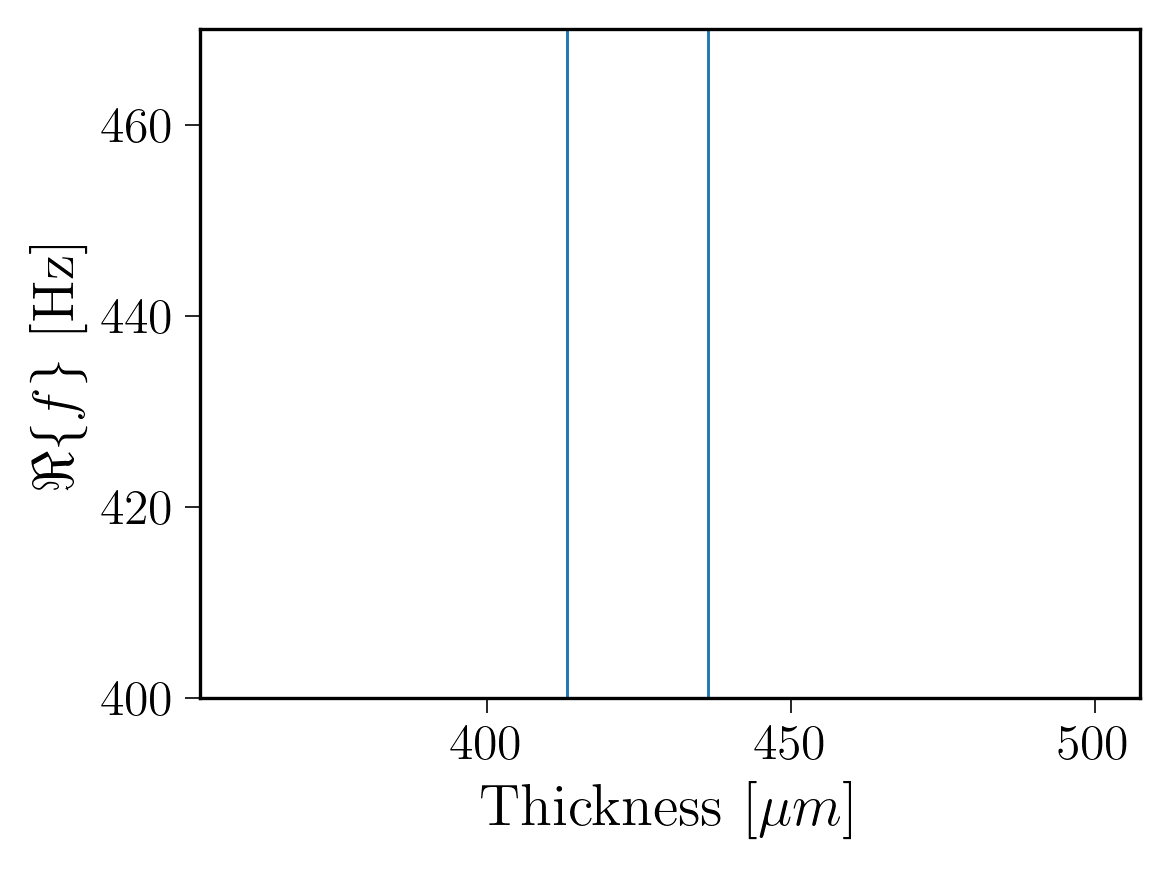

In [11]:
for t, p, r in zip(thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [t]*len(p), color="k", marker="x", alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylabel("$\Re\{f\}$ [Hz]")
plt.xlabel("Thickness [$\mu m$]")
plt.ylim(ylim)
plt.savefig("poles_vs_thickness.pdf")